# Exploratory Data Analysis on Titanic Dataset

This notebook performs exploratory data analysis (EDA) on the Titanic dataset. It includes data loading, cleaning, visualization, and insights generation.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style of seaborn
sns.set(style='whitegrid')

In [10]:
# Load the Titanic dataset
df = sns.load_dataset('titanic')

# Display the shape of the dataset
df.shape

(891, 15)

In [11]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

age            177
embarked         2
deck           688
embark_town      2
dtype: int64

In [15]:
# Handle missing values
# Age: Impute with median
df['age'] = df['age'].fillna(df['age'].median())
# Embarked: Impute with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

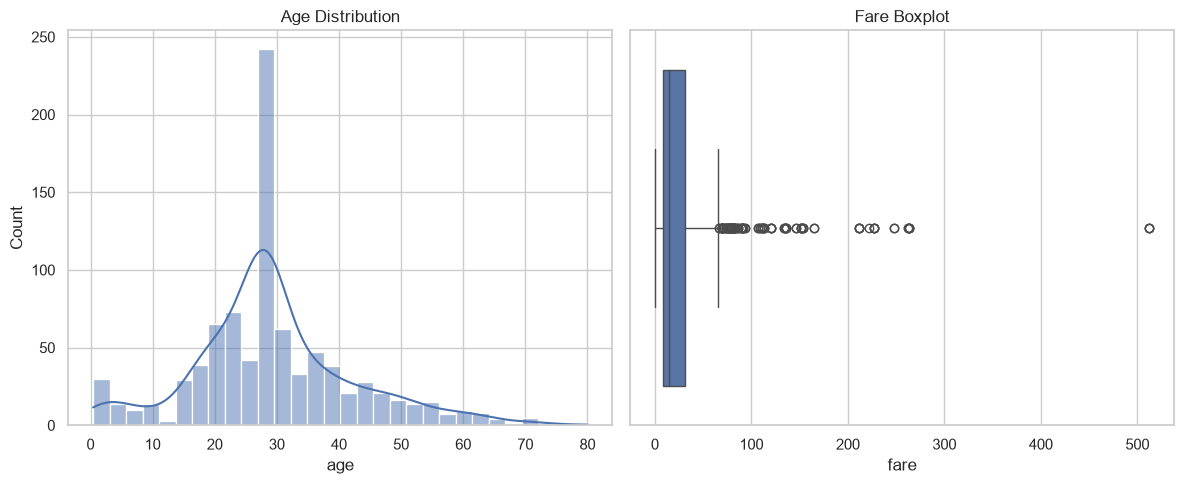

In [18]:
# Univariate analysis: Age and Fare
plt.figure(figsize=(12, 5))

# Age Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')

# Fare Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['fare'])
plt.title('Fare Boxplot')

plt.tight_layout()
plt.show()

In [19]:
# Bivariate analysis: Survival rate by Sex
survival_rate_sex = df.groupby('sex')['survived'].mean()
survival_rate_sex

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [20]:
# Bivariate analysis: Survival rate by Pclass
survival_rate_pclass = df.groupby('pclass')['survived'].mean()
survival_rate_pclass

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

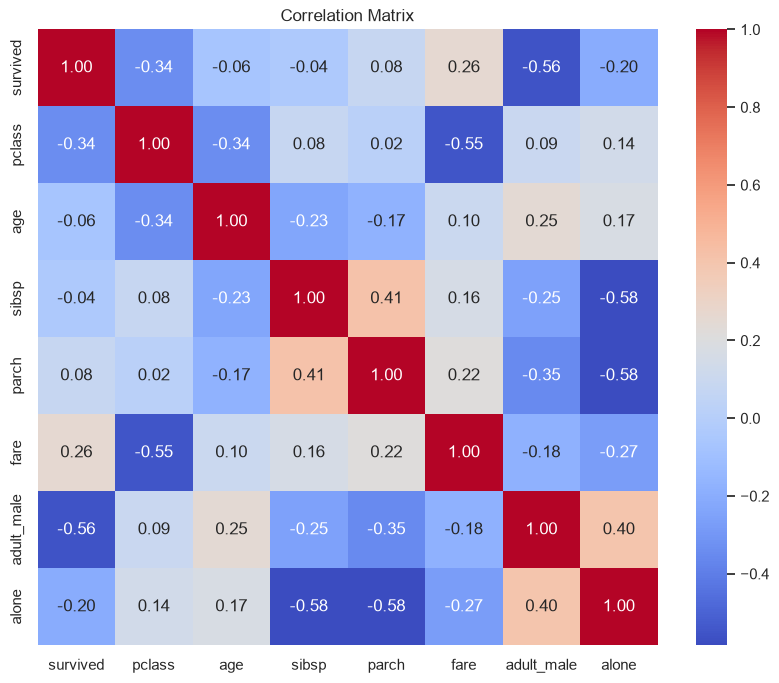

In [23]:
# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [24]:
# Save cleaned data for modeling
df.to_csv('../analytics/titanic_cleaned.csv', index=False)